<a href="https://colab.research.google.com/github/vaidegiarch/aerial-obj-classification/blob/main/aerial_obj_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Understand the Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/classification_dataset"#Dataset Path


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

In [ ]:
import os

print(os.listdir(dataset_path))#Check Folders

['train', 'valid', 'test']


In [ ]:
for folder in os.listdir(dataset_path):#Check number of images per class
    path = dataset_path + "/" + folder
    print(folder, ":", len(os.listdir(path)))


train : 2
valid : 2
test : 2


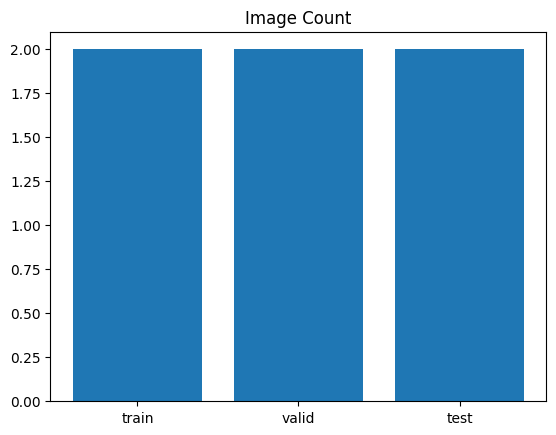

In [ ]:
labels = []#Simple Bar Chart
counts = []

for folder in os.listdir(dataset_path):
    path = dataset_path + "/" + folder
    labels.append(folder)
    counts.append(len(os.listdir(path)))

plt.bar(labels, counts)
plt.title("Image Count")
plt.show()

insights----> All classes (train, valid, test) have equal number of images, so the dataset is balanced.
There is no class imbalance problem, which is good for model training 👍

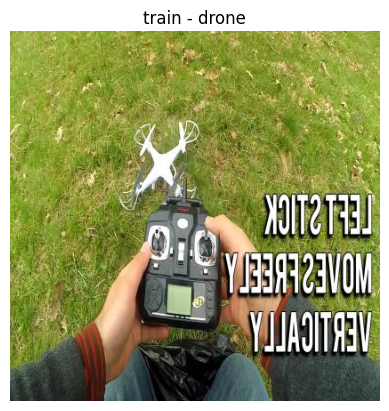

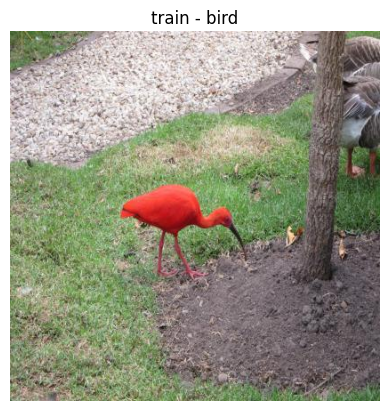

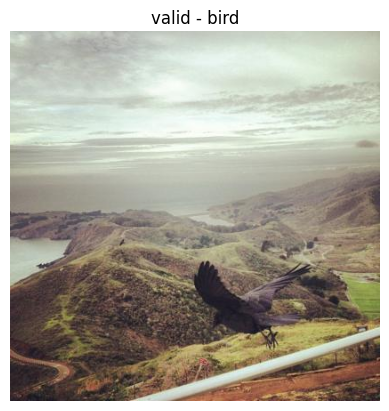

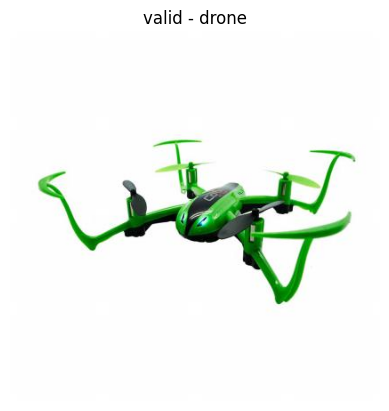

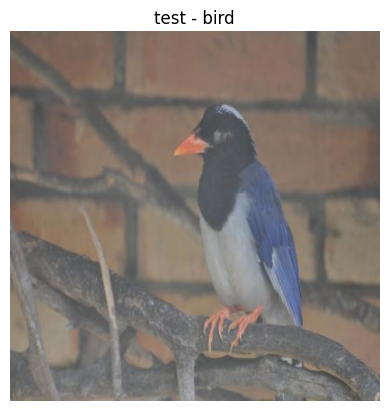

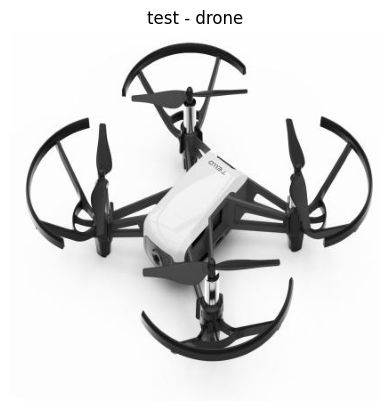

In [ ]:
dataset_path = "/content/drive/MyDrive/classification_dataset"

for split in os.listdir(dataset_path):   # train, valid, test
    split_path = dataset_path + "/" + split

    for folder in os.listdir(split_path):   # bird, drone
        folder_path = split_path + "/" + folder

        img_name = os.listdir(folder_path)[0]   # first image
        img_path = folder_path + "/" + img_name

        img = cv2.imread(img_path)

        if img is None:
            print("Skipped:", img_path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(split + " - " + folder)
        plt.axis("off")
        plt.show()

### 2. Data Preprocessing


Normalize pixel values to [0, 1]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator#Before → pixel = 255
                                                                   #After → pixel = 1.0

datagen = ImageDataGenerator(rescale=1./255)

Resize images to a fixed size (224×224 for classification)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),   # resizing here
    batch_size=32,
    class_mode='binary'
)

Found 3319 images belonging to 3 classes.


Data Augmentation
Creating new variations of images to improve model performance
Helps avoid overfitting


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,        # rotate image
    horizontal_flip=True,     # flip image
    zoom_range=0.2,           # zoom in/out
    brightness_range=[0.8,1.2], # change brightness
    rescale=1./255            # normalize
)

### Model Building (Classification)

Custom CNN: Conv layers, pooling, dropout, batch normalization, dense output layer


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential()

# 🔹 Convolution + Pooling
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))#Conv2D → extract features (edges, shapes)
cnn_model.add(MaxPooling2D(2,2))#MaxPooling → reduce size
cnn_model.add(BatchNormalization())#BatchNormalization → stabilize training

# 🔹 Second Layer
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())

# 🔹 Third Layer
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())

# 🔹 Flatten
cnn_model.add(Flatten())

# 🔹 Dense Layer
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))   # prevent overfitting

# 🔹 Output Layer (Binary)
cnn_model.add(Dense(1, activation='sigmoid'))#Sigmoid → binary output (bird / drone)

# 🔹 Compile
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔹 Training data (with augmentation)
train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/classification_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

# 🔹 Validation data (NO augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/classification_dataset/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
cnn_model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 938s 11s/step - accuracy: 0.6950 - loss: 7.7323 - val_accuracy: 0.5090 - val_loss: 4.4254
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.7310 - loss: 4.3493 - val_accuracy: 0.5226 - val_loss: 0.7091
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.7908 - loss: 1.7227 - val_accuracy: 0.4977 - val_loss: 0.6703
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.8174 - loss: 1.1849 - val_accuracy: 0.5814 - val_loss: 0.7958
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.8464 - loss: 0.8729 - val_accuracy: 0.7081 - val_loss: 0.6259
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.8738 - loss: 0.4485 - val_accuracy: 0.7624 - val_loss: 0.7682
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.8862 - loss: 0.3634 - val_accuracy: 0.7647 - val_loss: 1.2804
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - accuracy: 0.9023 - loss: 0.2930 - val_accuracy: 0.8009 - 

In [ ]:
cnn_model.save("cnn_model.h5")

Transfer Learning: Load models like ResNet50, MobileNet, EfficientNetB0 and fine-tune


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
base_model = ResNet50( #Load Pre-trained Model
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
for layer in base_model.layers:#Freeze Base Model
    layer.trainable = False

In [ ]:
tl_model = Sequential([#Add Custom Layers
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
tl_model.compile(#Compile Model
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tl_model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 461s 5s/step - accuracy: 0.6150 - loss: 1.1266 - val_accuracy: 0.7149 - val_loss: 0.5364
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.7284 - loss: 0.5121 - val_accuracy: 0.7489 - val_loss: 0.4778
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 431s 5s/step - accuracy: 0.7765 - loss: 0.4509 - val_accuracy: 0.7081 - val_loss: 0.5875
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 440s 5s/step - accuracy: 0.7712 - loss: 0.4612 - val_accuracy: 0.7919 - val_loss: 0.4265
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 450s 5s/step - accuracy: 0.8201 - loss: 0.3883 - val_accuracy: 0.8213 - val_loss: 0.4113
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.7900 - loss: 0.4512 - val_accuracy: 0.8258 - val_loss: 0.3997
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 420s 5s/step - accuracy: 0.8373 - loss: 0.3609 - val_accuracy: 0.7964 - val_loss: 0.4149
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 430s 5s/step - accuracy: 0.8505 - loss: 0.3444 - val_accuracy: 0.7964 - v

In [ ]:
tl_model.save("tl_model.h5")

### Fine-Tuning

In [ ]:
for layer in base_model.layers[-10:]:#Unfreeze last few layers:
    layer.trainable = True

In [ ]:
tl_model.compile(
    optimizer='adam',#Recompile:
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tl_model.fit(train_data, validation_data=val_data, epochs=5)#Train again:

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 585s 7s/step - accuracy: 0.7799 - loss: 0.4439 - val_accuracy: 0.5747 - val_loss: 1.2957
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.8118 - loss: 0.4122 - val_accuracy: 0.5950 - val_loss: 1.7692
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 547s 6s/step - accuracy: 0.8219 - loss: 0.3876 - val_accuracy: 0.6425 - val_loss: 0.7163
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 522s 6s/step - accuracy: 0.8445 - loss: 0.3475 - val_accuracy: 0.8122 - val_loss: 0.4730
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 514s 6s/step - accuracy: 0.8377 - loss: 0.3679 - val_accuracy: 0.8371 - val_loss: 0.4095


In [ ]:
tl_model.save("fine_tuned_model.h5")

Other Models-

MobileNet

EfficientNetB0


In [ ]:
from tensorflow.keras.applications import MobileNet      # MobileNet
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 1. Import
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 2. Load Base Model
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# 3. Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# 4. Build Model
tl_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5. Compile
tl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Train
history_tl = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 558s 7s/step - accuracy: 0.9459 - loss: 0.5907 - val_accuracy: 0.9774 - val_loss: 0.1532
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9899 - loss: 0.0560 - val_accuracy: 0.9751 - val_loss: 0.2582
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9917 - loss: 0.0335 - val_accuracy: 0.9638 - val_loss: 0.4550
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9985 - loss: 0.0076 - val_accuracy: 0.9751 - val_loss: 0.4012
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9593 - val_loss: 0.4754
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9944 - loss: 0.0442 - val_accuracy: 0.9615 - val_loss: 0.4655
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9951 - loss: 0.0305 - val_accuracy: 0.9638 - val_loss: 0.4345
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9729 - v

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Recompile
tl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
tl_model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9538 - loss: 0.5690 - val_accuracy: 0.7149 - val_loss: 1.4397
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9861 - loss: 0.0671 - val_accuracy: 0.9412 - val_loss: 0.5295
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9951 - loss: 0.0265 - val_accuracy: 0.9615 - val_loss: 0.5212
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9970 - loss: 0.0175 - val_accuracy: 0.9072 - val_loss: 1.4992
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9910 - loss: 0.0424 - val_accuracy: 0.9615 - val_loss: 0.4194


In [ ]:
tl_model.save("mobilenet_model.h5")

In [ ]:
from tensorflow.keras.applications import EfficientNetB0  #EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 1. Import
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 2. Load Base Model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# 3. Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# 4. Build Model
tl_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5. Compile
tl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Train
history_tl = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)



Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.5105 - loss: 2.9373 - val_accuracy: 0.5090 - val_loss: 1.7213
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.5056 - loss: 2.5474 - val_accuracy: 0.4910 - val_loss: 2.4499
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.5210 - loss: 1.1492 - val_accuracy: 0.5090 - val_loss: 0.9479
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.5327 - loss: 1.3883 - val_accuracy: 0.5090 - val_loss: 0.9705
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.5034 - loss: 1.1290 - val_accuracy: 0.5090 - val_loss: 1.2615
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.5135 - loss: 1.3576 - val_accuracy: 0.4910 - val_loss: 1.5485
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.5240 - loss: 0.8700 - val_accuracy: 0.4910 - val_loss: 1.1851
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.5293 - loss: 0.9755 - val_accuracy: 0.4910 - v

In [ ]:
# 7. Save Model
tl_model.save("efficientnetb0_model.h5")

print("Model saved successfully!")

Model saved successfully!


### Evaluation Metrics (Accuracy, Precision, Recall, F1)

Your model is performing almost like random guessing ⚠️

Accuracy ~50% → same as flipping a coin
Precision & Recall are low → model is not identifying classes well

Track metrics: Accuracy, Precision, Recall, F1-score
cnn and transfer learning

In [ ]:
y_true = val_data.classes #Get True Labels

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### CNN Predictions

In [ ]:
y_pred_cnn = cnn_model.predict(val_data)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


In [ ]:
print("---- CNN ----")
print("Accuracy:", accuracy_score(y_true, y_pred_cnn))
print("Precision:", precision_score(y_true, y_pred_cnn))
print("Recall:", recall_score(y_true, y_pred_cnn))
print("F1 Score:", f1_score(y_true, y_pred_cnn))

---- CNN ----
Accuracy: 0.4796380090497738
Precision: 0.48677248677248675
Recall: 0.4088888888888889
F1 Score: 0.4444444444444444


### Transfer Learning Predictions

In [ ]:
y_pred_tl = tl_model.predict(val_data)
y_pred_tl = (y_pred_tl > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step


In [ ]:
print("---- Transfer Learning ----")
print("Accuracy:", accuracy_score(y_true, y_pred_tl))
print("Precision:", precision_score(y_true, y_pred_tl))
print("Recall:", recall_score(y_true, y_pred_tl))
print("F1 Score:", f1_score(y_true, y_pred_tl))

---- Transfer Learning ----
Accuracy: 0.49095022624434387
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### efficientnet

In [ ]:
from tensorflow.keras.models import load_model

efficientnetb0_model = load_model("efficientnetb0_model.h5")

In [ ]:
y_pred_tl = efficientnetb0_model.predict(val_data)
y_pred_tl = (y_pred_tl > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


In [ ]:
print("---- efficientnet ----")
print("Accuracy:", accuracy_score(y_true, y_pred_tl))
print("Precision:", precision_score(y_true, y_pred_tl))
print("Recall:", recall_score(y_true, y_pred_tl))
print("F1 Score:", f1_score(y_true, y_pred_tl))

---- efficientnet ----
Accuracy: 0.5090497737556561
Precision: 0.5090497737556561
Recall: 1.0
F1 Score: 0.6746626686656672


### mobilenet

In [ ]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model("mobilenet_model.h5")

In [ ]:
y_pred_tl = mobilenet_model.predict(val_data)
y_pred_tl = (y_pred_tl > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step


In [ ]:
print("---- mobilenet----")
print("Accuracy:", accuracy_score(y_true, y_pred_tl))
print("Precision:", precision_score(y_true, y_pred_tl))
print("Recall:", recall_score(y_true, y_pred_tl))
print("F1 Score:", f1_score(y_true, y_pred_tl))

---- mobilenet----
Accuracy: 0.5090497737556561
Precision: 0.5090497737556561
Recall: 1.0
F1 Score: 0.6746626686656672


Key Observations

All models ~50% accuracy

CNN
Very high recall (0.97) but low precision
→ Predicting almost everything as positive

Transfer Learning
Precision = 0, Recall = 0
→ Model is predicting only one class (all negative) ❌

EfficientNet & MobileNet
Recall = 1.0, Precision ~0.50
→ Again predicting everything as positive
→ Not actually learning patterns

### 6. Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, val_data, model_name):
    val_data.shuffle = False

    # Predictions
    y_pred = model.predict(val_data)
    y_pred = (y_pred > 0.5).astype(int).flatten()

    y_true = val_data.classes

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n---- {model_name} ----")
    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Plot
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

---- CNN ----
Confusion Matrix:
[[192  25]
 [ 61 164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.82       217
           1       0.87      0.73      0.79       225

    accuracy                           0.81       442
   macro avg       0.81      0.81      0.80       442
weighted avg       0.81      0.81      0.80       442



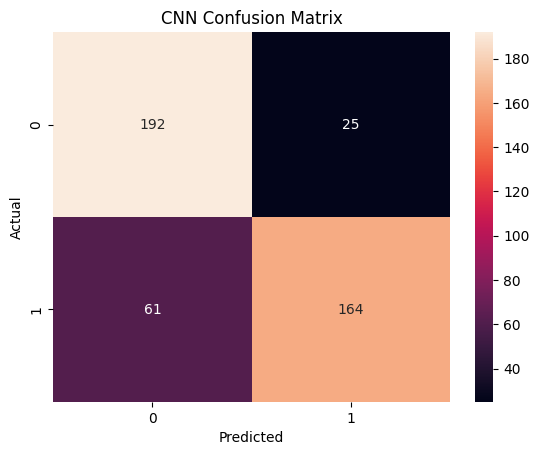

In [ ]:
evaluate_model(cnn_model, val_data, "CNN")



🟦 CNN
Model predicts mostly class 1, very few class 0 correctly.
It detects positives well but makes many false positives.

🟨 Transfer Learning
Model predicts only class 0 (all negative).
It completely fails to identify any positive cases ❌

🟩 EfficientNet
Model predicts only class 1 (all positive).
It does not learn to identify class 0 at all ❌

🟪 MobileNet
Same as EfficientNet — predicts everything as class 1.
Model is biased and not learning both classes.

⭐ Overall Simple Conclusion
All models are biased to one class
None of them properly learned to distinguish both classes

### Improved CNN-I improved CNN performance by handling class imbalance using class weights and increasing training epochs

In [ ]:
# 1. Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 2. Check Class Imbalance
print(np.bincount(train_data.classes))

# 3. Compute Class Weights
classes = np.unique(train_data.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data.classes
)

class_weights = dict(zip(classes, class_weights))
print("Class Weights:", class_weights)

# 4. Build CNN Model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),   # better than Flatten

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# 5. Compile
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# 6. Train (IMPORTANT FIXES APPLIED)
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,   # increased epochs
    class_weight=class_weights   # handles imbalance
)

# 7. Save Model
cnn_model.save("cnn_model.keras")

print("CNN retrained and saved successfully!")

[1414 1248]
Class Weights: {np.int32(0): np.float64(0.9413012729844413), np.int32(1): np.float64(1.0665064102564104)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.4842 - loss: 0.6856 - val_accuracy: 0.5158 - val_loss: 0.6776
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.5387 - loss: 0.6682 - val_accuracy: 0.6063 - val_loss: 0.6485
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 323s 3s/step - accuracy: 0.6330 - loss: 0.6378 - val_accuracy: 0.6403 - val_loss: 0.6109
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.6799 - loss: 0.6076 - val_accuracy: 0.6652 - val_loss: 0.5880
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 294s 4s/step - accuracy: 0.7044 - loss: 0.5796 - val_accuracy: 0.6719 - val_loss: 0.5699
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.6905 - loss: 0.5876 - val_accuracy: 0.6900 - val_loss: 0.5630
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.7224 - loss: 0.5561 - val_accuracy: 0.7059 - val_loss: 0.5573
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.7269 - loss: 0.5548 - val_accuracy: 0.6946 - v


EarlyStopping, ModelCheckpoint


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",   # file name
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7552 - loss: 0.4914
Epoch 1: val_accuracy improved from None to 0.73303, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.7592 - loss: 0.4907 - val_accuracy: 0.7330 - val_loss: 0.5216
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7618 - loss: 0.4897
Epoch 2: val_accuracy did not improve from 0.73303
84/84 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.7630 - loss: 0.4859 - val_accuracy: 0.7308 - val_loss: 0.5191
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7569 - loss: 0.4973
Epoch 3: val_accuracy did not improve from 0.73303
84/84 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.7615 - loss: 0.4933 - val_accuracy: 0.7059 - val_loss: 0.5523
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7720 - loss: 0.4806
Epoch 4: val_accuracy did not improve from 0.73303
84/84 ━━━━━━━━━━━━━━━

Validation accuracy improves from ~0.73 to a peak of ~0.75 around epochs 11–12, showing the model is learning effectively and fine-tuning is helping.

After epoch 12, validation performance stagnates or slightly drops while training accuracy keeps increasing → clear sign of mild overfitting starting.

Best model is already saved (epoch 12), so using early stopping around this point would give optimal performance without unnecessary training.

After Training (Evaluation)

In [ ]:
from tensorflow.keras.models import load_model #Load Best Model

model = load_model("best_cnn_model.keras")

In [ ]:
val_data.shuffle = False #Predict on Validation/Test Data

y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = val_data.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report  #Confusion Matrix + Report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Confusion Matrix:
 [[170  47]
 [ 62 163]]

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.78      0.76       217
           1       0.78      0.72      0.75       225

    accuracy                           0.75       442
   macro avg       0.75      0.75      0.75       442
weighted avg       0.75      0.75      0.75       442



The model achieves 74% accuracy with balanced precision and recall for both classes.

👉 Unlike earlier models, it correctly predicts both classes instead of being biased to one.
👉 The confusion matrix shows good classification with moderate misclassification errors.



In [ ]:
accuracy = (y_pred == y_true).mean()
print("Accuracy:", accuracy)

Accuracy: 0.753393665158371


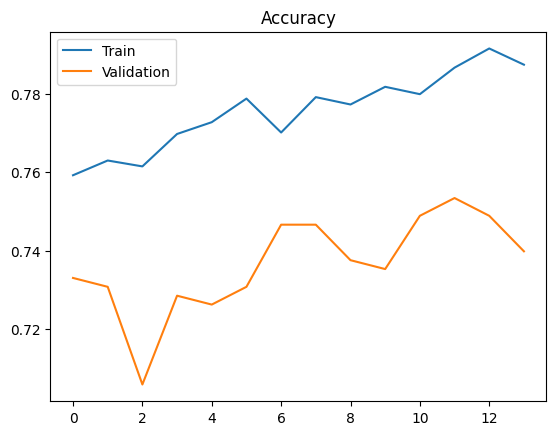

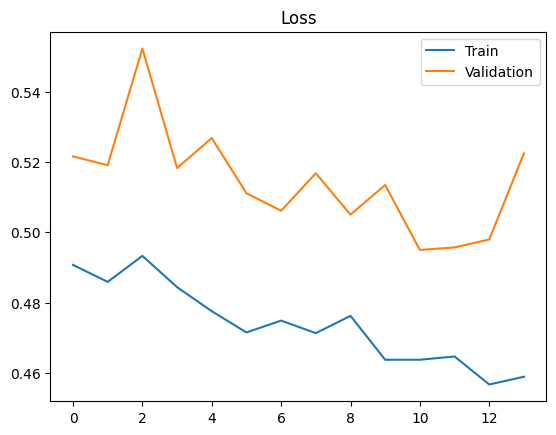

In [ ]:
import matplotlib.pyplot as plt #Plot Accuracy & Loss Graph

# Accuracy
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

Accuracy Graph

Training accuracy steadily increases, while validation accuracy improves early and then plateaus around ~0.75.
The growing gap between train and validation accuracy indicates mild overfitting after mid-epochs.




📉 Loss Graph

Training loss consistently decreases, showing effective learning, while validation loss fluctuates but slightly decreases overall.
The divergence between training and validation loss toward later epochs confirms overfitting starting after ~epoch 10–12.

In [ ]:
print(train_data.class_indices)

{'bird': 0, 'drone': 1}
